In [114]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
import pathlib
import random as rn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import argparse
import argparse
import json
import tensorboard
import tensorboardX
import os
import argparse
import json
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim 
import nni
from nni.nas.nn.pytorch import ModelSpace, LayerChoice, MutableConv2d, MutableBatchNorm2d, MutableReLU 
from nni.mutable import MutableExpression
from nni.mutable import Categorical
from pytorch_lightning import Trainer
from nni.nas.evaluator.pytorch import Lightning, ClassificationModule, Trainer
from nni.nas.experiment import NasExperiment
from nni.nas.space import model_context
from nni.nas.hub.pytorch import DARTS
from nni.nas.strategy import DARTS as DartsStrategy
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import transforms
from torchvision.datasets import CIFAR10
from nni.nas.experiment import NasExperiment
from nni.nas.evaluator import FunctionalEvaluator
from nni.nas.evaluator import FunctionalEvaluator
import nni.nas.strategy as strategy
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import genotypes
from pytorch_lightning.callbacks import ModelCheckpoint
torch.set_float32_matmul_precision('medium')
from tqdm import tqdm
from nni.nas.nn.pytorch import LayerChoice, ModelSpace,ValueChoice
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from pytorch_lightning import LightningModule, Trainer
from torchvision import datasets, transforms
from nni.nas.evaluator.pytorch import Classification
import argparse
import json
import tensorboard
import tensorboardX
import os
import argparse
import json
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim 
import nni
from nni.nas.nn.pytorch import ModelSpace, LayerChoice, MutableConv2d, MutableBatchNorm2d, MutableReLU,MutableLinear
from nni.nas.experiment.config import NasExperimentConfig
from pytorch_lightning import Trainer
from nni.nas.evaluator.pytorch import Lightning, ClassificationModule, Trainer
from nni.nas.experiment import NasExperiment
from nni.nas.space import model_context
from nni.nas.hub.pytorch import DARTS
from nni.nas.strategy import DARTS as DartsStrategy
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import transforms
from torchvision.datasets import CIFAR10
from nni.nas.experiment import NasExperiment
from nni.nas.evaluator import FunctionalEvaluator
from nni.nas.evaluator import FunctionalEvaluator
import nni.nas.strategy as strategy
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from nni.experiment.config import utils, ExperimentConfig
#from ops import AvgPool,DilConv,SepConv
import genotypes
from pytorch_lightning.callbacks import ModelCheckpoint
torch.set_float32_matmul_precision('medium')
from tqdm import tqdm
from nni.nas.nn.pytorch import LayerChoice, ModelSpace,ValueChoice
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from pytorch_lightning import LightningModule, Trainer
from torchvision import datasets, transforms
from nni.nas.evaluator.pytorch import Classification

In [115]:
import numpy as np
import torchvision.transforms.functional as F
from PIL import Image

def equalize(img):
    img = np.array(img)  # Convert to NumPy
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.equalizeHist(img)
    return Image.fromarray(img)  # Convert back to PIL


In [116]:
data_dir = 'C:/Users/senti/Desktop/GTSDB'
train_path = 'C:/Users/senti/Desktop/GTSDB/Train'
test_path = 'C:/Users/senti/Desktop/GTSDB/Test'
height = 32
width = 32

In [117]:
batch_size = 150
seed = 42

In [118]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }

In [119]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.transforms.functional import equalize


train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomCrop(32, padding=5),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.Lambda(equalize),  # Now it works correctly!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

])



val_transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Resize to match training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
full_val_dataset = datasets.ImageFolder(root=train_path, transform=val_transform)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, _ = random_split(train_dataset, [train_size, val_size])
_, val_dataset = random_split(full_val_dataset, [train_size, val_size])  # Corrected!

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
valid_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)


data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"Images shape: {images.shape}") 
print(f"Labels shape: {labels.shape}")  
print(f"Labels: {labels}") 


Images shape: torch.Size([16, 3, 32, 32])
Labels shape: torch.Size([16])
Labels: tensor([14, 13,  2,  6,  2, 38, 14,  7, 20, 38,  8, 30, 25,  5, 13,  7])


In [120]:
for i, (inputs, labels) in enumerate(train_loader):
    print(f"Batch {i+1}, Labels: {labels}")


Batch 1, Labels: tensor([ 1,  9,  7, 36,  5,  5, 12, 10,  1, 17, 18, 10, 38, 26, 38, 21])
Batch 2, Labels: tensor([ 7, 25, 11, 25,  3,  2, 28, 27, 18, 25, 13, 23,  1, 13,  8,  8])
Batch 3, Labels: tensor([38,  2,  2, 13, 10, 22, 13,  2,  1, 19,  1, 11,  9, 31, 38,  9])
Batch 4, Labels: tensor([11,  8, 16, 11, 25, 13,  3,  2,  6, 12, 25, 10, 25, 35,  2, 30])
Batch 5, Labels: tensor([ 7, 13,  8,  9,  8, 10, 39, 15, 17,  2, 10,  6, 12, 33, 38,  4])
Batch 6, Labels: tensor([ 8, 34, 12,  5, 13,  9,  2,  7, 30, 10,  5, 32,  4,  5, 28,  9])
Batch 7, Labels: tensor([42, 38,  3, 12, 14,  9, 11,  5, 14, 12, 36, 10,  7,  1, 11,  9])
Batch 8, Labels: tensor([17, 13,  8,  4, 13, 24, 10, 16, 38, 11, 12,  2, 10, 33,  1, 33])
Batch 9, Labels: tensor([ 2, 10, 12,  8, 10, 25,  1, 23,  8, 12, 20, 33, 10, 41, 25, 13])
Batch 10, Labels: tensor([30, 29, 20,  1, 25,  1,  5, 35, 14, 40, 12, 12, 28,  4,  3, 10])
Batch 11, Labels: tensor([26, 12,  6,  2,  4, 38, 17,  8, 13, 23, 25, 11,  9, 18,  4, 10])
Batch 12

In [121]:
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")


Training dataset size: 682
Validation dataset size: 171


In [122]:
# For train dataset
train_labels = [label for _, label in train_dataset]

# For validation dataset
val_labels = [label for _, label in val_dataset]

In [123]:
unique_list = list(set(train_labels))
print(unique_list)  # No need to append 43 manually


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..

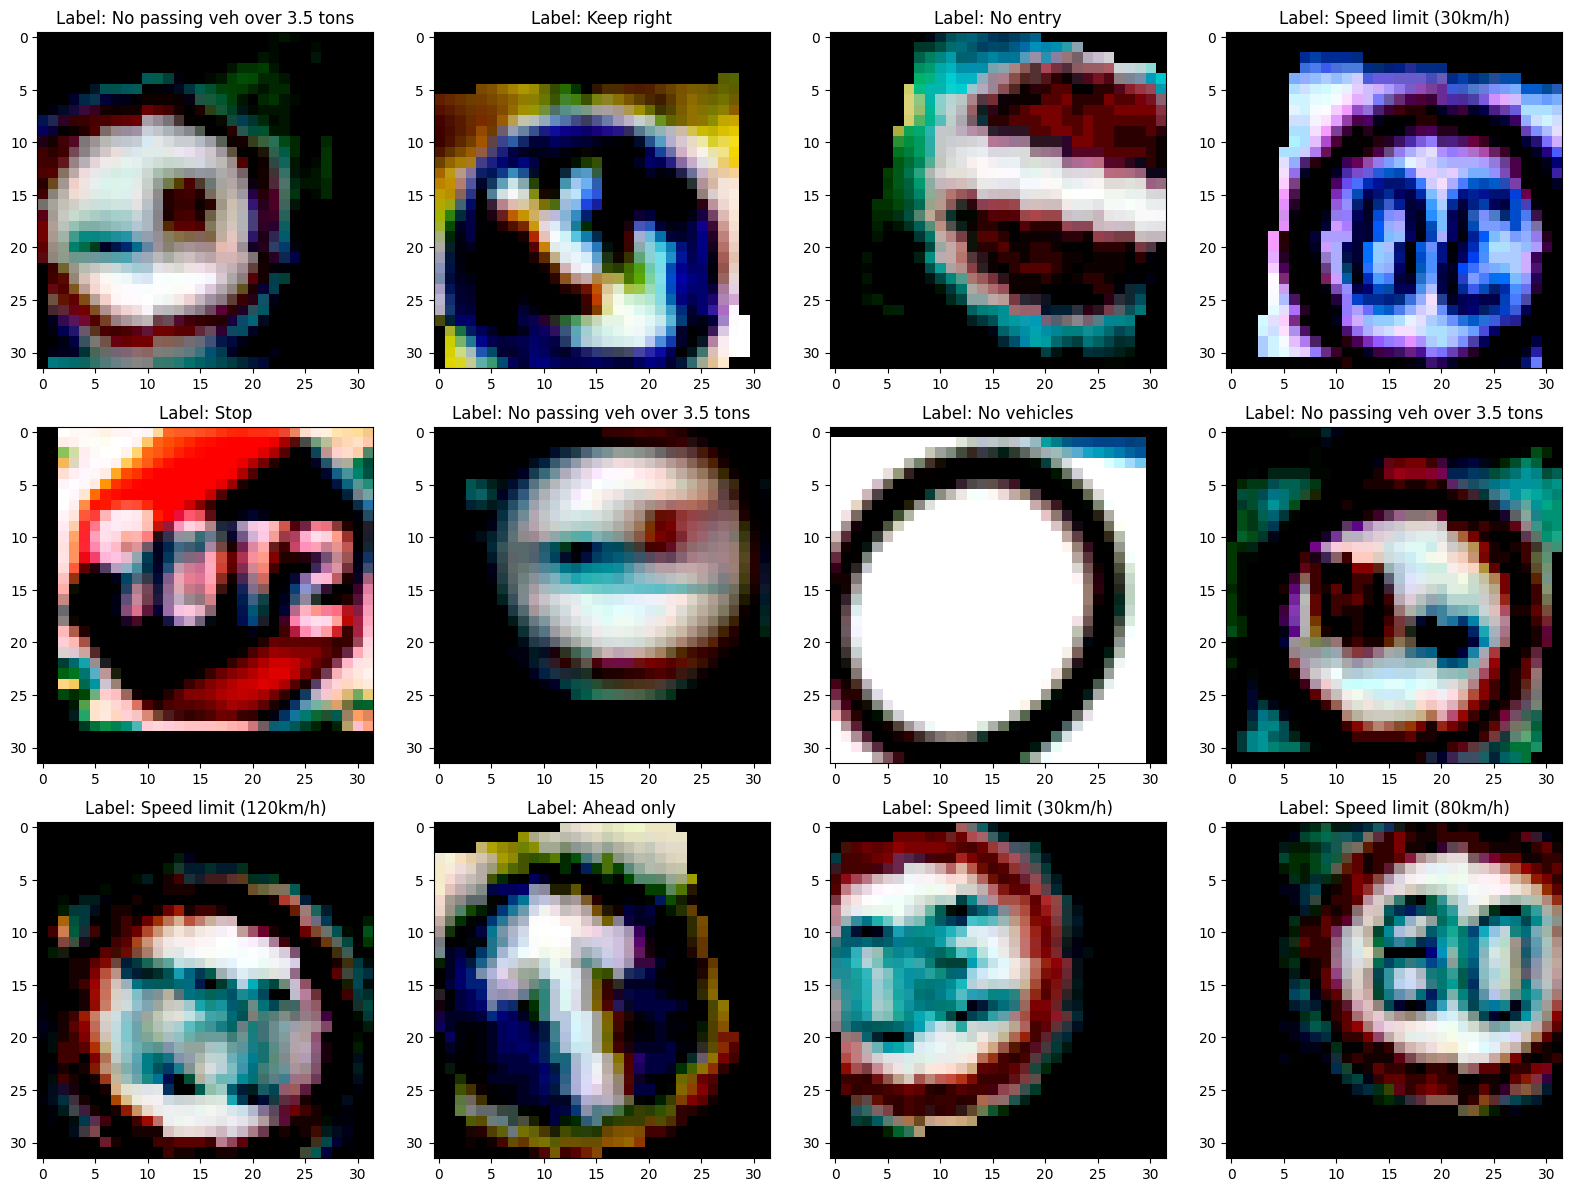

In [124]:
import matplotlib.pyplot as plt
import numpy as np


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


data_iter = iter(train_loader)


images, labels = next(data_iter)

fig, ax = plt.subplots(3, 4)
fig.set_size_inches(16, 12)

for i in range(3):
    for j in range(4):
        img = images[i * 4 + j]
        label = labels[i * 4 + j].item() 
        
        ax[i, j].imshow(img.permute(1, 2, 0), cmap='gray') 
        ax[i, j].set_title(f"Label: {classes[label]}") 

plt.tight_layout()
plt.show()


In [125]:
@nni.trace
class DartsClassificationModule(ClassificationModule):
    def __init__( self,learning_rate: float = 0.001,weight_decay: float = 0.,auxiliary_loss_weight: float = 0.4,max_epochs: int = 600):
        super().__init__(learning_rate=learning_rate, weight_decay=weight_decay, export_onnx=False,num_classes=10)        
        self.auxiliary_loss_weight = auxiliary_loss_weight
        self.max_epochs = max_epochs
        self.learning_rate = learning_rate


    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate, momentum=0.9, weight_decay=0.)
        return {
            'optimizer': optimizer,
            'lr_scheduler': torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
        }

    def training_step(self, batch, batch_idx):
        """Training step, customized with auxiliary loss."""
        x, y = batch
        if self.auxiliary_loss_weight:
            y_hat, y_aux = self(x)
            loss_main = self.criterion(y_hat, y)
            loss_aux = self.criterion(y_aux, y)
            self.log('train_loss_main', loss_main)
            self.log('train_loss_aux', loss_aux)
            loss = loss_main + self.auxiliary_loss_weight * loss_aux
        else:
            y_hat = self(x)
            loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        for name, metric in self.metrics.items():
            self.log('train_' + name, metric(y_hat, y), prog_bar=True)
        return loss

    def on_train_epoch_start(self):
        # Set drop path probability before every epoch. This has no effect if drop path is not enabled in model.
        #self.model.set_drop_path_prob(self.model.drop_path_prob * self.current_epoch / self.max_epochs)

        # Logging learning rate at the beginning of every epoch
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'])


In [126]:

class CustomDARTSSpace(ModelSpace):
    def __init__(self, input_channels=3, channels=64, num_classes=10, layers=5,verbose =0, drop_path_prob = 0.1):
        super(CustomDARTSSpace, self).__init__()

        #________________________________________________________________________________________________________________________
        #Inizialization
        self.layers = nn.ModuleList()
        self.drop_path_prob = drop_path_prob
        self.verbose = verbose


        #________________________________________________________________________________________________________________________
        #Channel choices
        layer0_out = 16
        layer1_out = nni.choice('layer1_out_channels', [16,32,64])
        layer2_out= nni.choice('layer2_out_channels', [16,32,64])
        layer3_out= nni.choice('layer3_out_channels', [16,32,64])
        layer4_out = nni.choice('layer4_out_channels', [16,32,64])
        layer5_out= nni.choice('layer5_out_channels', [16,32,64])
        layer6_out= nni.choice('layer6_out_channels', [16,32,64])
        layer7_out= 22
        
        #________________________________________________________________________________________________________________________
        #Layer 0
        self.preliminary_layer = nn.Conv2d(3, layer0_out, kernel_size=3, padding=0, bias=False)
        self.layer0_bn = torch.nn.BatchNorm2d(layer0_out)
        self.layer0_relu = torch.nn.ReLU(inplace=True)
        
        #________________________________________________________________________________________________________________________
        #Layer 1
        layer1 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1 ),
                MutableConv2d(layer0_out, layer1_out, kernel_size=3),
                MutableBatchNorm2d(layer1_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer0_out, layer1_out, kernel_size=3),
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableBatchNorm2d(layer1_out),
                MutableReLU()
            )
        ], label='layer_1')
        self.layers.append(layer1)
        
        #________________________________________________________________________________________________________________________
        #Layer 2
        layer2 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableConv2d(layer1_out, layer2_out, kernel_size=3),
                MutableBatchNorm2d(layer2_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer1_out, layer2_out, kernel_size=3),
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableBatchNorm2d(layer2_out),
                MutableReLU()
            )
        ], label='layer_2')
        self.layers.append(layer2)
        
        #________________________________________________________________________________________________________________________
        #Layer 3
        layer3 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableConv2d(layer2_out, layer3_out, kernel_size=3),
                MutableBatchNorm2d(layer3_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer2_out, layer3_out, kernel_size=3),
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableBatchNorm2d(layer3_out),
                MutableReLU()
            )
        ], label='layer_3')
        self.layers.append(layer3)
                #________________________________________________________________________________________________________________________
        #Layer 4
        layer4 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableConv2d(layer3_out, layer4_out, kernel_size=3),
                MutableBatchNorm2d(layer4_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer3_out, layer4_out, kernel_size=3),
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableBatchNorm2d(layer4_out),
                MutableReLU()
            )
        ], label='layer_4')
        self.layers.append(layer4)
                #________________________________________________________________________________________________________________________
        #Layer 5
        layer5 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableConv2d(layer4_out, layer5_out, kernel_size=3),
                MutableBatchNorm2d(layer5_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer4_out, layer5_out, kernel_size=3),
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableBatchNorm2d(layer5_out),
                MutableReLU()
            )
        ], label='layer_5')
        self.layers.append(layer5)
                #________________________________________________________________________________________________________________________
        #Layer 6
        layer6= LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableConv2d(layer5_out, layer6_out, kernel_size=3),
                MutableBatchNorm2d(layer6_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer5_out, layer6_out, kernel_size=3),
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableBatchNorm2d(layer6_out),
                MutableReLU()
            )
        ], label='layer_6')
        self.layers.append(layer6)
                #________________________________________________________________________________________________________________________
        #Layer 7
        layer7 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableConv2d(layer6_out, layer7_out, kernel_size=3),
                MutableBatchNorm2d(layer7_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer6_out, layer7_out, kernel_size=3),
                nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                MutableBatchNorm2d(layer7_out),
                MutableReLU()
            )
        ], label='layer_7')
        self.layers.append(layer7)
        

        
        #________________________________________________________________________________________________________________________
        #Linear
        self.pool = nn.AdaptiveAvgPool2d((3, 3))
        feature1 = nni.choice('feature1', [32, 64, 128])
        feature2 = nni.choice('feature2', [32 ,64, 128])
        feature3 = nni.choice('feature3', [32, 64])
        self.fc1 = MutableLinear(198, feature1) 
        self.fc2 = MutableLinear(feature1, feature2) 
        self.fc3 = MutableLinear(feature2, feature3)  
        self.relu = nn.ReLU()
        self.classifier = MutableLinear(feature3, num_classes)

    def forward(self, x):
        #________________________________________________________________________________________________________________________
        #Layer 0
        x = self.preliminary_layer(x)
        X = self.layer0_bn(x)
        x = self.layer0_relu(x)
        if self.verbose == 1 :
            print(f'After preliminary layer: {x.shape}')
        #________________________________________________________________________________________________________________________
        #Layer 1 to n
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if self.verbose == 1 :
                print(f'After layer {i+1}: {x.shape}')
            if i == 1 or i == 3 or i == 6:
                x = nn.AvgPool2d(kernel_size=2, stride=2)(x)
                if self.verbose == 1 :
                    print(f'After avg pooling: {x.shape}')
        
        #________________________________________________________________________________________________________________________
        #Adaprive pool
        x =  self.pool(x)
        if self.verbose == 1 :
            print(f'After adaptive pooling: {x.shape}')

        #________________________________________________________________________________________________________________________
        #Flatten
        x = torch.flatten(x, 1)
        if self.verbose == 1 :
            print(f'After flattening: {x.shape}')
        #________________________________________________________________________________________________________________________
        
        x = self.fc1(x)
        x= self.relu(x)
        if self.verbose == 1 :
            print(f'After fc1: {x.shape}')
        x = self.fc2(x)
        x= self.relu(x)
        if self.verbose == 1 :
            print(f'After fc2: {x.shape}')
        x = self.fc3(x)
        x= self.relu(x)
        if self.verbose == 1 :
            print(f'After fc3: {x.shape}')
        #________________________________________________________________________________________________________________________
        #Classification 
        x = self.classifier(x)

        
        if self.verbose == 1 :
            print(f'After classifier: {x.shape}')
        #self.first_iter = False
        return x

    def set_drop_path_prob(self, drop_path_prob):
        self.drop_path_prob = drop_path_prob
        for layer in self.layers:
            if hasattr(layer, 'set_drop_path_prob'):
                layer.set_drop_path_prob(drop_path_prob)


In [127]:

class CustomDARTSSpaceK3(ModelSpace):
    def __init__(self, input_channels, channels, num_classes, layers, verbose):
        super(CustomDARTSSpaceK3, self).__init__()
        #self.first_iter = True
        self.layers = nn.ModuleList()
        self.drop_path_prob = 0.0  
        self.preliminary_layer = nn.Conv2d(3, 8, kernel_size=3, padding=0, bias=False)
        self.verbose = verbose

        layer1_in = 8
        layer1_out = nni.choice('layer1_out_channels', [2,4,8,16,32,64])
        layer2_out= nni.choice('layer2_out_channels', [2,4,8,16,32,64])
        layer3_out= nni.choice('layer3_out_channels', [2,4,8,16,32,64])
        layer4_out= nni.choice('layer4_out_channels', [2,4,8,16,32,64])
        layer5_out = 22 
        
        layer1 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableConv2d(8, layer1_out, kernel_size=1),
                MutableBatchNorm2d(layer1_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(8, layer1_out, kernel_size=1),
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableBatchNorm2d(layer1_out),
                MutableReLU()
            )
        ], label='layer_1')
        self.layers.append(layer1)
        
        layer2 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableConv2d(layer1_out, layer2_out, kernel_size=1),
                MutableBatchNorm2d(layer2_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer1_out, layer2_out, kernel_size=1),
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableBatchNorm2d(layer2_out),
                MutableReLU()
            )
        ], label='layer_2')
        self.layers.append(layer2)
        
        layer3 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableConv2d(layer2_out, layer3_out, kernel_size=1),
                MutableBatchNorm2d(layer3_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer2_out, layer3_out, kernel_size=1),
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableBatchNorm2d(layer3_out),
                MutableReLU()
            )
        ], label='layer_3')
        self.layers.append(layer3)
        
        layer4 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableConv2d(layer3_out, layer4_out, kernel_size=1),
                MutableBatchNorm2d(layer4_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer3_out, layer4_out, kernel_size=1),
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableBatchNorm2d(layer4_out),
                MutableReLU()
            )
        ], label='layer_4')
        self.layers.append(layer4)
        
        layer5 = LayerChoice([
            nn.Sequential(
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableConv2d(layer4_out, layer5_out, kernel_size=1),
                MutableBatchNorm2d(layer5_out),
                MutableReLU()
            ),   
            nn.Sequential(
                MutableConv2d(layer4_out, layer5_out, kernel_size=1),
                nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                MutableBatchNorm2d(layer5_out),
                MutableReLU()
            )
        ], label='layer_5')
        self.layers.append(layer5)
        
        # Ensure the number of inputs to fc1 is close to but not exceeding 200
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc1 = nn.Linear(198, 128) 
        self.fc2 = nn.Linear(128, 64) 
        self.fc3 = nn.Linear(64, 32)  
        self.relu = nn.ReLU()
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        # Kernel: 3
        # Initial shape: 32x32
        #print(f'Input shape: {x.shape}')
        x = self.preliminary_layer(x)
        # After preliminary layer: 31x31
        if self.verbose == 1 :
            print(f'After preliminary layer: {x.shape}')
        
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if self.verbose == 1 :
                print(f'After layer {i+1}: {x.shape}')
            
            # Add a AvgPool2d layer after the third layer to reduce spatial dimensions
            if i == 2 or i == 4:
                x = nn.AvgPool2d(kernel_size=2, stride=2)(x)
                if self.verbose == 1 :
                    print(f'After avg pooling: {x.shape}')
        

        x =  nn.AvgPool2d(kernel_size=2, stride =2)(x)
        if self.verbose == 1 :
            print(f'After adaptive pooling: {x.shape}')
        
        x = torch.flatten(x, 1)
        if self.verbose == 1 :
            print(f'After flattening: {x.shape}')
        
        x = self.fc1(x)
        x= self.relu(x)
        if self.verbose == 1 :
            print(f'After fc1: {x.shape}')
        x = self.fc2(x)
        x= self.relu(x)
        if self.verbose == 1 :
            print(f'After fc2: {x.shape}')
        x = self.fc3(x)
        x= self.relu(x)
        if self.verbose == 1 :
            print(f'After fc3: {x.shape}')
        
        x = self.classifier(x)
        if self.verbose == 1 :
            print(f'After classifier: {x.shape}')
        #self.first_iter = False
        return x

    def set_drop_path_prob(self, drop_path_prob):
        self.drop_path_prob = drop_path_prob
        for layer in self.layers:
            if hasattr(layer, 'set_drop_path_prob'):
                layer.set_drop_path_prob(drop_path_prob)

In [128]:
# Checkpoint 
checkpoint_callback = ModelCheckpoint(
    monitor='train_acc', 
    dirpath='./checkpoints',
    filename='GTSDB-best-checkpoint',
    save_top_k=1,
    mode='max'
    
)

In [129]:
from nni.nas.evaluator.pytorch import Lightning, Trainer

max_epochs = 200

evaluator = Lightning(
    DartsClassificationModule(1e-2, 0., 0., max_epochs),
    Trainer(
        accelerator="auto",
        callbacks=[checkpoint_callback],
        max_epochs=max_epochs
    ),
    train_dataloaders=train_loader,
    val_dataloaders=valid_loader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [130]:
strategy = DartsStrategy(gradient_clip_val=0.)
def search(log_dir: str, batch_size: int = 128):

    # Define model search space
    model_space = CustomDARTSSpace(input_channels=3, channels=64, num_classes=10, layers=7, verbose=0)
    model_space.set_drop_path_prob(0.)

    # Run NAS experiment
    exp_config = NasExperimentConfig.default(model_space, evaluator, strategy)
    exp_config.experiment_working_directory = "./DartsCheckpoints"
    exp_config.experiment_name = "Darts_search"
    exp_config.trial_concurrency = 1
    experiment = NasExperiment(model_space, evaluator, strategy, config = exp_config)
    experiment.run()

    return experiment


In [131]:
experiment_results = search("./",64)

[2025-03-05 17:11:49] Config is not provided. Will try to infer.
[2025-03-05 17:11:49] Strategy is found to be a one-shot strategy. Setting execution engine to "sequential" and format to "raw".
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17:11:49] WARNING: `training_service` will be ignored for sequential execution engine.
[2025-03-05 17

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[2025-03-05 17:11:49] ERROR: Model 1 fails to be executed.
[2025-03-05 17:11:49] ERROR: Strategy failed to execute.


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
exported_arch = experiment_results.export_top_models(formatter='dict')[0]

exported_arch

In [ ]:
checkpoint_path = './checkpoints/best-checkpoint-v9.ckpt'

checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

model_checkpoint = CustomDARTSSpaceK3(input_channels=3, channels=64, num_classes=43, layers=5,verbose =0)

model_state_dict = model_checkpoint.state_dict()
pretrained_state_dict = checkpoint['state_dict']

filtered_state_dict = {k: v for k, v in pretrained_state_dict.items() if k in model_state_dict}

model_state_dict.update(filtered_state_dict)

model_checkpoint.load_state_dict(model_state_dict)

torch.save(model_checkpoint,"testmodel.pkt")

if 'global_step' in checkpoint:
    print("Global Step:", checkpoint['global_step'])

if 'callbacks' in checkpoint and isinstance(checkpoint['callbacks'], dict):
    for key, callback in checkpoint['callbacks'].items():
        if isinstance(callback, dict) and 'best_model_score' in callback:
            print("Best Model Score (Train Accuracy):", callback['best_model_score'].item())

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_checkpoint = model_checkpoint.to(device) 

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_checkpoint.parameters(), lr=1e-2, weight_decay=3e-4)

if 'optimizer_state_dict' in checkpoint:
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(checkpoint['optimizer_state_dict'])
model_checkpoint.set_drop_path_prob(0.2)
model_checkpoint.train()
def continue_training(model, train_loader, criterion, optimizer, num_epochs, start_epoch=0):
    top_acc = 0.0
    for epoch in range(start_epoch, num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (inputs, labels) in enumerate(train_loader):
            # Check the range of labels before moving to device      
            # Move inputs and labels to the same device as the model
            inputs = inputs.to(device, dtype=torch.float32)  # Ensure inputs are of type float32
            labels = labels.to(device, dtype=torch.long)  # Ensure labels are of type long
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            
            # Debug: Check shapes and values

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        accuracy = 100 * correct / total
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.2f}%')
        if accuracy > top_acc:
            top_acc = accuracy
    print('Finished Training')

continue_training(model_checkpoint, train_loader, criterion, optimizer, num_epochs=600, start_epoch=0)
print(f'Top accuracy: {top_acc}')

In [ ]:

def evaluate_model(model, valid_loader, criterion):
    model.eval()  
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(valid_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    valid_loss = running_loss / len(valid_loader)
    accuracy = 100 * correct / total

    print(f'Validation Loss: {valid_loss:.4f}, Validation Accuracy: {accuracy:.2f}%')

    return valid_loss, accuracy

valid_loss, valid_accuracy = evaluate_model(model_checkpoint, valid_loader, criterion)
